In [ ]:
!pip install keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 35.0 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import matthews_corrcoef, precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import keras_cv

from collections import Counter

In [ ]:
from tensorflow.keras.models import Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Path to dataset in Google Drive
PATH = '/content/drive/MyDrive/'
route_dataset = os.path.join(PATH, 'TRAINING_CFP/')
BATCH_SIZE = 32
img_dim = 224
IMG_SIZE = (img_dim, img_dim)

print("TRAINING AND VALIDATION DATA: ")
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    route_dataset,
    validation_split = 0.3,
    subset = "both",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = 'categorical',
    shuffle=True,
    seed=200
)

DATOS DE ENTRENAMIENTO Y VALIDACIÓN: 
Found 7391 files belonging to 2 classes.
Using 5174 files for training.
Using 2217 files for validation.


In [ ]:
class_names = val_ds.class_names
print("PROBLEM CLASSES:", class_names)

CLASES DEL PROBLEMA: ['glaucoma', 'normal']


In [ ]:
# Validation split is equally divided into validation and test sets (total 30% of data)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take((val_batches) // 2)
val_ds = val_ds.skip((val_batches) // 2)

In [ ]:
train_size = train_ds.cardinality().numpy()*BATCH_SIZE
val_size = val_ds.cardinality().numpy()*BATCH_SIZE
test_size = test_ds.cardinality().numpy()*BATCH_SIZE

print(f'Training size: {train_size} images')
print(f'Validation size: {val_size} images')
print(f'Test size: {test_size} images')

Tamaño entrenamiento: 5184 imágenes
Tamaño validación: 1120 imágenes
Tamaño prueba: 1120 imágenes


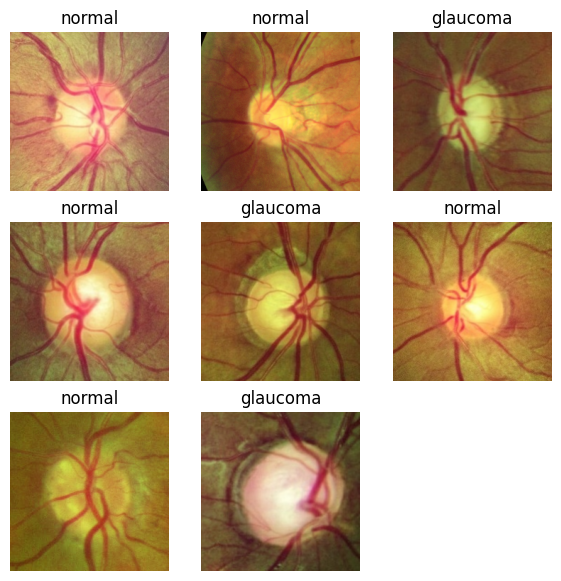

In [ ]:
# # Show some data examples, from train dataset
plt.figure(figsize=(7, 7))
for images, labels in train_ds.take(1):
  for i in range(8):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    class_index = np.argmax(labels[i].numpy()) # One hot encoding data labels
    plt.title(class_names[class_index])
    plt.axis("off")

In [ ]:
# Define AUTOTUNE for performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Voting functions for ensemble models
def average_voting(model_probabilities):
  avg = 0
  for probs in model_probabilities:
    avg += probs
  avg = avg / len(model_probabilities)
  return avg

def majority_voting(model_probabilities):
  mv = 0
  for probs in model_probabilities:
    mv += probs
  mv = mv / len(model_probabilities)
  return np.round(mv)

In [ ]:
# Metric evaluation function for models or predictions. It can be customized between basic classification metrics.
def metric_models(modelos_o_preds, metric = 'prec', X_val=None, y_val=None):
    accuracies = {}

    if len(y_val.shape) > 1 and y_val.shape[1] > 1:
        y_val = np.argmax(y_val, axis=1)

    for i, item in enumerate(modelos_o_preds):
        if callable(getattr(item, "predict", None)):
            predicts = np.argmax(item.predict(X_val), axis=1)
        else:
            predicts = item

        if metric == 'prec':
          measure = precision_score(y_val, predicts)
        elif metric == 'acc':
          measure = accuracy_score(y_val, predicts)
        elif metric == 'recall':
          measure = recall_score(y_val, predicts)
        elif metric == 'f1':
          measure = f1_score(y_val, predicts)
        elif metric == 'mcc':
          measure = matthews_corrcoef(y_val, predicts)
        else:
          raise NameError("Metric specified should be one of the following: acc, prec, recall, f1, mcc")
        accuracies[f"Model_{i+1}"] = measure

    return accuracies

In [ ]:
# Weighted Voting based on model precision
def abwv_ensemble(models, X_val, Y_val):
    # Extract normalized weights
    accuracies = metric_models(models, 'prec', X_val, Y_val)
    weights = np.array(list(accuracies.values()))
    weights = weights / np.sum(weights)  # Normalization
    # Predictions
    preds_probas = [model.predict(X_val) for model in models]
    # Weigthed predictions
    weighted_preds = np.zeros_like(preds_probas[0]) 
    for i, preds in enumerate(preds_probas):
        weighted_preds += preds * weights[i]  # Calculate weighted sum
    # Weighted final predictions
    final_preds = weighted_preds

    return final_preds

In [ ]:
# Exponential version of previous method
def average_weighted_voting_exponential(models, X_val, Y_val):
  accuracies = metric_models(models, 'prec', X_val, Y_val)
  accuracies2 = np.array(list(accuracies.values()))
  alpha = np.exp(-20 * (1 - accuracies2))
  alpha /= np.sum(alpha)
  preds_probas = [model.predict(X_val) for model in models]
  weighted_preds = np.zeros_like(preds_probas[0])
  for i, preds in enumerate(preds_probas):
    weighted_preds += preds * alpha[i]
  final_preds = weighted_preds
  return final_preds

In [ ]:
# Data augmentation pipeline
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal_and_vertical'),
  tf.keras.layers.RandomSharpness(factor=(0.5, 1)),
  tf.keras.layers.RandomRotation(factor = 45/360,  fill_mode='constant'),
  tf.keras.layers.RandomZoom((-0.2, 0.2), fill_mode='constant')
])

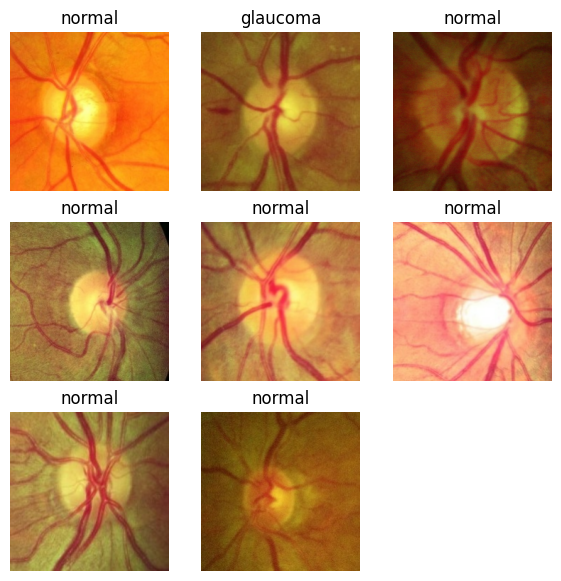

In [ ]:

plt.figure(figsize=(7, 7))
for images, labels in train_dataset.take(1):
  for i in range(8):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    class_index = np.argmax(labels[i].numpy()) 
    plt.title(class_names[class_index]) 
    plt.axis("off")

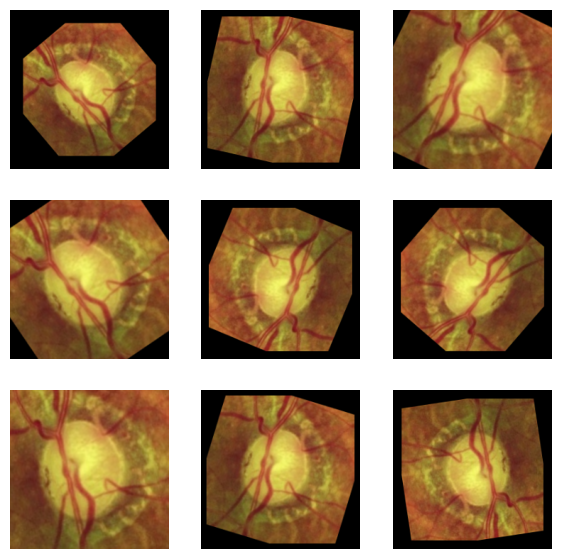

In [ ]:
# Augmentation examples
import random
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(7, 7))
  first_image = image[random.randint(0,16)]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [ ]:
# Three used models: InceptionV3, ResNet50 and DenseNet169
IMG_SHAPE = IMG_SIZE + (3,)

# preprocess_input = tf.keras.applications.inception_v3.preprocess_input
# preprocess_input = tf.keras.applications.resnet50.preprocess_input
preprocess_input = tf.keras.applications.densenet.preprocess_input

# base_model = tf.keras.applications.InceptionV3(input_shape=IMG_SHAPE, include_top=False, weights='imagenet', pooling='none')
# base_model = tf.keras.applications.ResNet50(input_shape=IMG_SHAPE, include_top=False, weights='imagenet', pooling = 'none')
base_model = tf.keras.applications.DenseNet169(input_shape=IMG_SHAPE, include_top=False, weights='imagenet', pooling='none')

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

In [ ]:
# First training phase: Freezed base model (pretrained)
base_model.trainable = False

In [ ]:
base_model.summary()

Model: "densenet169"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 12,642,880 (48.23 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 12,642,880 (48.23 MB)

In [ ]:
from tensorflow.keras import regularizers

In [ ]:
# Classification head construction on top of base model
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, kernel_initializer = 'he_uniform', kernel_regularizer=regularizers.l2(l2 = 2e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('leaky_relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(256, kernel_initializer = 'he_uniform', kernel_regularizer=regularizers.l2(l2 = 4e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('leaky_relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(128, kernel_initializer = 'he_uniform', kernel_regularizer=regularizers.l2(l2 = 6e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('leaky_relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(2, activation = 'softmax')(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
# Hyperparameters for first training phase
base_learning_rate = 1e-3
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=base_learning_rate, momentum=0.9),
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add (Add)                            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_1 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ densenet169 (Functional)             │ (None, 7, 7, 1664)          │      12,642,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1664)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         852,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 13,663,426 (52.12 MB)

 Trainable params: 1,018,754 (3.89 MB)

 Non-trainable params: 12,644,672 (48.24 MB)

In [ ]:
len(model.trainable_variables)

14

In [ ]:
initial_epochs = 30

In [ ]:
# Calculate class weights to handle data imbalance
labels = [y.numpy() for _, y in train_dataset.unbatch()]
labels = tf.convert_to_tensor(labels)

counts = tf.reduce_sum(labels, axis=0)
total_samples = tf.reduce_sum(counts)
class_weights = total_samples / (len(counts) * counts)
weights = {i: class_weights[i].numpy() for i in range(len(counts))}

print("Calculated weights:", weights)

In [ ]:
# Training phase with personalized callbacks and class weights
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=val_dataset,
                    verbose = 2,
                    class_weight = weights,
                    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
                    #callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15),
                    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-8, min_delta = 0.001,verbose=1 )],

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy', weight= "bold")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title('Training and Validation Loss', weight= "bold")
plt.xlabel('epoch')
plt.grid()
plt.show()

# **Fine tuning**

In [ ]:
base_model.trainable = True

In [ ]:
print("Number of layers in the base model: ", len(base_model.layers))

In [ ]:
print("Number of layers in the base model: ", len(base_model.layers))

fine_tune_at = 0#125

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

model.compile(loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
              optimizer = tf.keras.optimizers.Adam(learning_rate=base_learning_rate*0.1),
              metrics=['accuracy'])

# train_size = len(train_dataset)

# steps_per_epoch = train_size // BATCH_SIZE
# decay_steps = steps_per_epoch * 80

# cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
#     initial_learning_rate=base_learning_rate*0.1,
#     decay_steps=decay_steps,
#     alpha= 1e-7
# )

# model.compile(loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
#               optimizer = tf.keras.optimizers.Adam(learning_rate=cosine_decay),
#               metrics=['accuracy'])

# for layer in base_model.layers:
#   layer.trainable = True

In [ ]:
model.summary()

In [ ]:
len(model.trainable_variables)

In [ ]:
fine_tune_epochs = 80
total_epochs =  initial_epochs + fine_tune_epochs
#total_epochs =   fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=val_dataset,
                         callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                                    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=8
                                    , min_lr=1e-8, min_delta = 0.01)],
                         verbose = 2,
                         class_weight = weights )

In [ ]:
acc2 = acc+history_fine.history['accuracy']
val_acc2 = val_acc+history_fine.history['val_accuracy']

loss2 = loss+history_fine.history['loss']
val_loss2 = val_loss+ history_fine.history['val_loss']

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(acc2, label='Training Accuracy')
plt.plot(val_acc2, label='Validation Accuracy')
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.ylim([0.4, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy', weight= "bold")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(loss2, label='Training Loss')
plt.plot(val_loss2, label='Validation Loss')
plt.plot([initial_epochs-1,initial_epochs-1],
plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper center')
plt.title('Training and Validation Loss', weight= "bold")
plt.xlabel('epoch')
plt.grid()
plt.show()

In [ ]:
# Evaluation of the model on the test dataset
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9137 - loss: 0.3837
Test accuracy : 0.9116071462631226


In [ ]:
y_test = []
X_test = []

for images, labels in test_dataset:
    X_test.append(images)
    y_test.append(labels)

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

In [ ]:
predicciones = model.predict(X_test)
etiquetas_predichas = (predicciones >= 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step


In [ ]:
etiquetas_predichas_int = np.argmax(etiquetas_predichas, axis=1)
y_test_int = np.argmax(y_test, axis=1)

In [ ]:
# Classification metrics (internal testing)
mcc = matthews_corrcoef(etiquetas_predichas_int, y_test_int)
precision = precision_score(etiquetas_predichas_int, y_test_int, average='macro')*100
recall = recall_score(etiquetas_predichas_int, y_test_int, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_int, y_test_int)*100
f1 = f1_score(etiquetas_predichas_int, y_test_int, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)
print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.8084223044293686
Precisión: 89.09 %
Recall: 91.80 %
Exactitud: 91.16 %
F1-score: 90.17 %


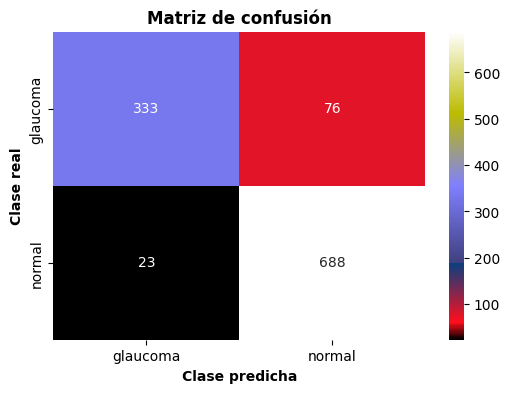

In [ ]:
cm = confusion_matrix(y_test_int, etiquetas_predichas_int, labels=[0., 1.])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="gist_stern", cbar=True,  xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("Confusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

report = classification_report(y_test_int, etiquetas_predichas_int, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    glaucoma       0.94      0.81      0.87       409
      normal       0.90      0.97      0.93       711

    accuracy                           0.91      1120
   macro avg       0.92      0.89      0.90      1120
weighted avg       0.91      0.91      0.91      1120



In [ ]:
#AUCROC calculation and best threshold selection
y_pred_prob = model.predict(X_test)

AUC = roc_auc_score(y_test, y_pred_prob)
AUC_macro = roc_auc_score(y_test, y_pred_prob, average="macro", multi_class="ovr")

print("AUC One-vs-Rest:", AUC)
print("AUC Macro:", AUC_macro)

fpr, tpr, THRESOLDS = roc_curve(y_test[:, 0], y_pred_prob[:, 0])
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr 
best_threshold = THRESOLDS[np.argmax(J_scores)]
print(f"Best thresold based on ROC curve: {best_threshold:.3f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step
AUC One-vs-Rest: 0.9662567615431965
AUC Macro: 0.9662567615431965
Mejor umbral basado en la curva ROC: 0.013


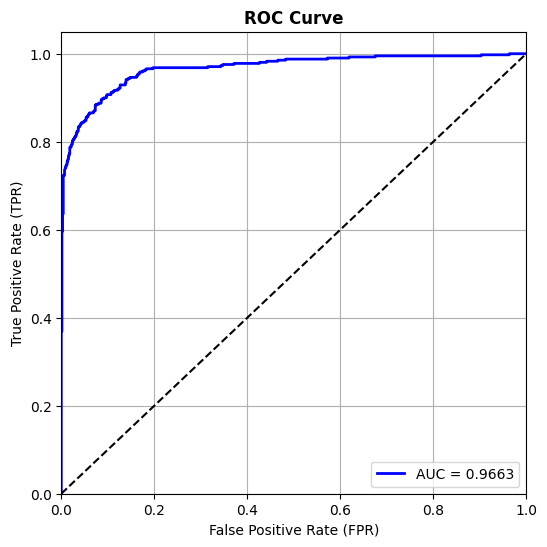

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
import cv2

In [ ]:
# Visualization of class activation maps using Grad-CAM
def compute_gradcam(img, gradcam_model):

    with tf.GradientTape() as tape:
        tape.watch(img)
        conv_output, pred = gradcam_model(img, training=False)
        pred_idx = tf.argmax(pred[0])
        class_channel = pred[:, pred_idx]

    grads = tape.gradient(class_channel, conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]

    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return (heatmap, pred)

In [ ]:
# auto adjust number of row,col (subplot) based on n figures
def auto_plot_fig_data(num_figures, verbose=True, fig_scale=2):
    num_cols = int((num_figures)**(1/2))
    num_rows = num_figures // num_cols
    if num_figures % num_cols != 0: num_rows += 1
    if 5 > num_cols < num_rows:
        num_rows, num_cols = num_cols, num_rows
    w = num_cols * fig_scale
    h = num_rows * fig_scale
    if verbose:
        print(f"num_figures: {num_figures}")
        print(f"(num_cols, num_rows): {(num_cols, num_rows)}")
    return {
        "num_cols": num_cols,
        "num_rows": num_rows,
        "w": w,
        "h": h
    }

In [ ]:
def visualize_gradcam(tfdata, gradcam_model, class_names, verbose=True):
    num_figures = sum([1 for _ in tfdata])
    fd = auto_plot_fig_data(num_figures, verbose)
    num_cols = fd['num_cols']
    num_rows = fd['num_rows']

    plt.figure(figsize=(fd['w'], fd['h']))
    for i, (image, label) in enumerate(tfdata):
        plt.subplot(num_rows, num_cols, i+1)

        #Iterate over the batch dimension
        for single_image, single_label in zip(image, label):
            image_tensor = tf.expand_dims(single_image, axis=0)  
            heat_map, pred = compute_gradcam(image_tensor, gradcam_model)
            heat_map = tf.expand_dims(heat_map, axis=-1)  # Assuming Z is 3 for (224, 224, 3) images
            heat_map = tf.image.resize(heat_map, (224, 224))

            plt.imshow(single_image.numpy().astype('uint8'))
            plt.imshow(heat_map, cmap='jet', alpha=0.4)
            plt.title(f"label: {class_names[np.argmax(single_label)]}\npred: {class_names[np.argmax(pred)]}")
            plt.axis("off")

    plt.tight_layout()

In [ ]:
grad_model = tf.keras.Model(
    [model.input], [model.get_layer(name='global_average_pooling2d').input, model.output]
)

In [ ]:
confidence_threshold = 0.7 # In case a thresold is needed
subset_size = 32  # Number of desired images to visualize

all_images = []
all_labels = []

for image_batch, label_batch in test_dataset:
    predictions = model.predict(image_batch, verbose=0)

    max_probs = np.max(predictions, axis=1)  
    predicted_labels = np.argmax(predictions, axis=1) 
    true_labels = np.argmax(label_batch, axis=1)  

    # Filter images with high confidence and correct prediction 
    mask = (predicted_labels == true_labels) & (max_probs > confidence_threshold)

    selected_images = image_batch.numpy()[mask]
    selected_labels = label_batch.numpy()[mask]

    all_images.extend(selected_images)
    all_labels.extend(selected_labels)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

# Verify if we have enough images with high confidence
if len(all_images) < subset_size:
    print(f"Warning: They were just found {len(all_images)} images with confidence > {confidence_threshold}. They will all be used.")
    subset_size = len(all_images) 

filtered_images = all_images[:subset_size]
filtered_labels = all_labels[:subset_size]

test_dataset_high_confidence = tf.data.Dataset.from_tensor_slices((filtered_images, filtered_labels))

test_dataset_high_confidence = (
    test_dataset_high_confidence
    .batch(1) 
    .prefetch(tf.data.experimental.AUTOTUNE)
)

print("Expected cardinality:", subset_size)
print("Real cardinality:", test_dataset_high_confidence.cardinality())

for image_batch, label_batch in test_dataset_high_confidence.take(1):
    print("Imágenes shape:", image_batch.shape)  # (1, 224, 224, 3)
    print("Etiquetas shape:", label_batch.shape)

In [ ]:
subset_size = 12
test_GRADCAM2 = test_dataset_high_confidence.skip(0).take(subset_size)

for image_batch, label_batch in test_dataset_high_confidence.take(1):
    print("Images shape:", image_batch.shape)
    print("Labels shape:", label_batch.shape)

In [ ]:
visualize_gradcam(test_GRADCAM2, grad_model, class_names=class_names)

## Meta model training

In [ ]:
# This section is intended to be run separately if needed. It trains the model for stacking purposes or MLP feature extraction.
# It is not part of the main training flow. 

In [ ]:
def extract_features(model, X, ln = -2):
    feature_extractor = Model(inputs=model.input, outputs=model.layers[ln].output)  # Extract features from the specified layer
    print("EXTRACTED FEATURES FROM LAYER", model.layers[ln].name )
    return feature_extractor.predict(X)

In [ ]:
# Loaded pretrained models for feature extraction
RESNET50 = os.path.join(PATH, 'CFP_RESNET50.keras')
INCEPTION = os.path.join(PATH, 'CFP_INCEPTION.keras')
DENSENET = os.path.join(PATH, 'CFP_DENSENET169.keras')

model1 =  tf.keras.models.load_model(RESNET50)
model2 =  tf.keras.models.load_model(DENSENET)
model3 =  tf.keras.models.load_model(INCEPTION)

model1.trainable = False
model2.trainable = False
model3.trainable = False

In [ ]:
# ENSEMBLE VIA MLP
model1_sin_softmax = tf.keras.Model(inputs=model1.input,outputs=model1.layers[-2].output)
model2_sin_softmax = tf.keras.Model(inputs=model2.input,outputs=model2.layers[-2].output)
model3_sin_softmax = tf.keras.Model(inputs=model3.input,outputs=model3.layers[-2].output)

# Freeze base models to not be re-trained and weights updated again
model1_sin_softmax.trainable = False
model2_sin_softmax.trainable = False
model3_sin_softmax.trainable = False

In [ ]:
input_common = tf.keras.Input(shape=model1_sin_softmax.input_shape[1:])
out1 = model1(input_common)
out2 = model2(input_common)
out3 = model3(input_common)

fusionCNN = tf.keras.layers.Concatenate()([out1, out2, out3])

x = tf.keras.layers.Dense(128, activation='relu')(fusionCNN)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
output = tf.keras.layers.Dense(2, activation='softmax')(x)

ensemble_model = Model(inputs=input_common, outputs=output)

ensemble_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

ensemble_model.summary()

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional_1 (Functional) │ (None, 2)              │     24,804,866 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional_2 (Functional) │ (None, 2)              │     13,663,426 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional_7 (Functional) │ (None, 2)              │     23,019,938 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 6)              │              0 │ functional_1[2][0],    │
│ (Concatenate)             │                        │                │ functional_2[2][0],    │
│                           │                        │                │ functional_7[2][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 128)            │            896 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128)            │              0 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 64)             │          8,256 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 2)              │            130 │ dense_4[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 61,497,512 (234.59 MB)

 Trainable params: 10,056 (39.28 KB)

 Non-trainable params: 61,487,456 (234.56 MB)

In [ ]:
# Superior MLP training. Note that the trained and validation datasets are splitted again for this purpose and avoid data leakage.
card = tf.data.experimental.cardinality(test_dataset).numpy()
print("Total number of batches:", card)

BATCHES = int(0.2 * card)

val_test_dataset = test_dataset.take(BATCHES)
train_test_dataset = test_dataset.skip(BATCHES)

print("Training batches for MLP:", tf.data.experimental.cardinality(train_test_dataset).numpy())
print("Validation batches for MLP:", tf.data.experimental.cardinality(val_test_dataset).numpy())

Número total de batches: 35
Batches para entrenamiento del MLP superior: 28
Batches para validación del MLP superior: 7


In [ ]:
history_ensemble = ensemble_model.fit(
    train_test_dataset,
    epochs=50,
    validation_data=val_test_dataset,
    verbose = 2
)

Epoch 1/50
28/28 - 109s - 4s/step - accuracy: 0.8092 - loss: 0.4562 - val_accuracy: 0.9018 - val_loss: 0.2881
Epoch 2/50
28/28 - 13s - 466ms/step - accuracy: 0.9219 - loss: 0.2298 - val_accuracy: 0.9062 - val_loss: 0.2936
Epoch 3/50
28/28 - 13s - 471ms/step - accuracy: 0.9308 - loss: 0.2115 - val_accuracy: 0.9018 - val_loss: 0.2865
Epoch 4/50
28/28 - 13s - 476ms/step - accuracy: 0.9241 - loss: 0.2164 - val_accuracy: 0.8973 - val_loss: 0.2786
Epoch 5/50
28/28 - 13s - 473ms/step - accuracy: 0.9263 - loss: 0.2123 - val_accuracy: 0.9062 - val_loss: 0.2763
Epoch 6/50
28/28 - 13s - 468ms/step - accuracy: 0.9263 - loss: 0.2113 - val_accuracy: 0.8973 - val_loss: 0.2732
Epoch 7/50
28/28 - 13s - 466ms/step - accuracy: 0.9286 - loss: 0.2225 - val_accuracy: 0.9018 - val_loss: 0.2680
Epoch 8/50
28/28 - 13s - 467ms/step - accuracy: 0.9275 - loss: 0.2096 - val_accuracy: 0.8929 - val_loss: 0.2660
Epoch 9/50
28/28 - 13s - 470ms/step - accuracy: 0.9241 - loss: 0.2057 - val_accuracy: 0.8884 - val_loss: 0

In [ ]:
acc = history_ensemble.history['accuracy']
val_acc = history_ensemble.history['val_accuracy']

loss = history_ensemble.history['loss']
val_loss = history_ensemble.history['val_loss']

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation in Ensemble: Accuracy', weight= "bold")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
#plt.ylim([0,1.0])
plt.title('Training and Validation in Ensemble: Loss', weight= "bold")
plt.xlabel('epoch')
plt.grid()
plt.show()

In [ ]:
pred1 = model1.predict(test_dataset)
pred2 = model2.predict(test_dataset)
pred3 = model3.predict(test_dataset)

35/35 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step


In [ ]:
features1 = extract_features(model1, test_dataset)
features2 = extract_features(model2, test_dataset)
features3 = extract_features(model3, test_dataset)

EXTRACTED FEATURES FROM LAYER dropout_2
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step
EXTRACTED FEATURES FROM LAYER dropout_5
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step
EXTRACTED FEATURES FROM LAYER dropout_8
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step


In [ ]:
y_test = []
X_test = []

for images, labels in test_dataset:
    X_test.append(images)
    y_test.append(labels)

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

In [ ]:
# !pip install lightgbm

In [ ]:
# Loading necessary libraries for meta-model construction
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, matthews_corrcoef, precision_score, recall_score, accuracy_score
from xgboost import XGBClassifier

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

X_meta_model = np.concatenate([pred1, pred2, pred3], axis=1)
# scaler1 = StandardScaler().fit(features1)
# scaler2 = StandardScaler().fit(features2)
# scaler3 = StandardScaler().fit(features3)

# features1= scaler1.transform(features1)
# features2 = scaler2.transform(features2)
# features3 = scaler3.transform(features3)

# preds1 = build_preds_entropy(pred1)
# preds2 = build_preds_entropy(pred2)
# preds3 = build_preds_entropy(pred3)

# predictions_ = [features1,features2, features3]
# predictions_ = [preds1,preds2, preds3]

# X_meta_model = np.concatenate(predictions_, axis=1)
# X_meta_model = scaler.fit_transform(X_meta_model)

Y_TEST = np.argmax(y_test, axis=1)
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(X_meta_model, y_test, test_size=0.2, random_state=42)
y_train_meta = np.argmax(y_train_meta, axis=1)
y_test_meta = np.argmax(y_test_meta, axis=1)

# Cross validation general
scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'mcc': make_scorer(matthews_corrcoef),
    'roc_auc': 'roc_auc'
}

# param_grid = {
#     'num_leaves': [31, 50, 100],
#     'max_depth': [10, 20, -1],
#     'learning_rate': [0.05, 0.1, 0.2],
#     'n_estimators': [50, 100, 200, 500],
#     'class_weight': ['balanced', None]
# }

# grid_search = GridSearchCV(
#     estimator=meta_model,
#     param_grid=param_grid,
#     cv=5,
#     scoring=scoring,
#     refit='mcc',
#     return_train_score=False,
#     verbose = 0
# )


## Metamodel with SVM

## Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'poly'}
meta_model = SVC(random_state=10, C = 0.1, class_weight='balanced', gamma = 0.1, kernel = 'poly', probability=True)
# meta_model.fit(X_meta_model, Y_TEST)

cv_results = cross_validate(
    meta_model,
    X_meta_model,
    Y_TEST,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

for metric in cv_results:
    print(f"{metric} average:", np.mean(cv_results[metric]))

fit_time promedio: 0.10248122215270997
score_time promedio: 0.0181488037109375
test_accuracy promedio: 0.9232142857142858
test_f1 promedio: 0.9416931502078605
test_precision promedio: 0.9096596437618109
test_recall promedio: 0.9761055845562888
test_mcc promedio: 0.8341848477360735
test_roc_auc promedio: 0.9700566576783226


In [ ]:
predictions = [pred1,pred2, pred3]
models = [model1, model2, model3]

In [ ]:
# Average voting
AV = average_voting(predictions)
# Majority voting
MV = majority_voting(predictions)
# Average Based Weighting Voting (ABWV)
ABWV = abwv_ensemble(models, X_test, y_test)
# Average Based Weighting Voting (ABWV) versión exponencial
ABWVe = average_weighted_voting_exponential(models, X_test, y_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step


In [ ]:
Stacking_meta_model = ABWVe

In [ ]:
# SVM
# etiquetas_predichas = (Stacking_meta_model > 0.5).astype(int)
# etiquetas_predichas_int = np.argmax(etiquetas_predichas, axis=1)
# y_test_int = y_test_meta

In [ ]:
# Ensemble metrics evaluation (internal testing in the CFP module)
mcc = matthews_corrcoef(etiquetas_predichas_int, y_test_int)
precision = precision_score(etiquetas_predichas_int, y_test_int, average='macro')*100
recall = recall_score(etiquetas_predichas_int, y_test_int, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_int, y_test_int)*100
f1 = f1_score(etiquetas_predichas_int, y_test_int, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)
print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.8230094203485395
Precisión: 89.58 %
Recall: 92.78 %
Exactitud: 91.79 %
F1-score: 90.83 %


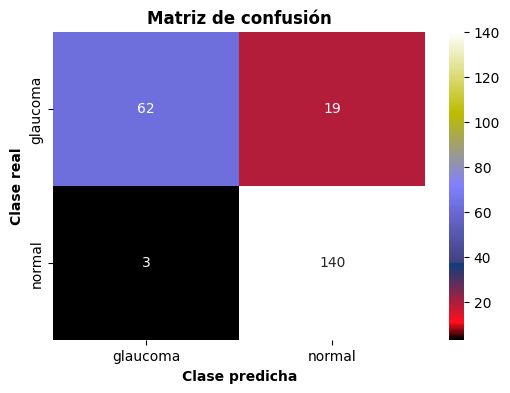

In [ ]:
cm = confusion_matrix(y_test_int, etiquetas_predichas_int, labels=[0., 1.])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="gist_stern", cbar=True,  xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("Confusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

In [ ]:
y_pred_prob = Stacking_meta_model
# y_pred_prob_int = np.argmax(y_pred_prob, axis=1)
#y_test = np.argmax(y_pred_prob_int, axis=1)
AUC = roc_auc_score(y_test, y_pred_prob)
AUC_macro = roc_auc_score(y_test, y_pred_prob, average="macro", multi_class="ovr")

print("AUC One-vs-Rest:", AUC)
print("AUC Macro:", AUC_macro)

fpr, tpr, THRESOLDS = roc_curve(y_test[:, 0], y_pred_prob[:, 0])
# fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, multi_class="ovr")
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr  # Sensibilidad - (1 - Especificidad)
best_threshold = THRESOLDS[np.argmax(J_scores)]
print(f"Best thresold based on ROC curve: {best_threshold:.3f}")

AUC One-vs-Rest: 0.9695923988734487
AUC Macro: 0.9695923988734487
Mejor umbral basado en la curva ROC: 0.013


In [ ]:
import joblib
joblib.dump(meta_model, '/content/drive/My Drive/CFP_SVM_PREDS.pkl') # Save the trained meta-model (CNN were saved individually in h5 format)

['/content/drive/My Drive/CFP_SVM_PREDS.pkl']

# **External validation**

In [ ]:
# MODEL = os.path.join(PATH, 'CFP_RESNET50.keras')
# model =  tf.keras.models.load_model(MODEL)
# model.trainable = False

In [ ]:
external_dir = os.path.join(PATH, 'TRAINING CFP/EXTERNAL VALIDATION/CFP')


In [ ]:
external_dataset = tf.keras.utils.image_dataset_from_directory(external_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE,
                                                                 label_mode = 'categorical'
                                                                 )

Found 125 files belonging to 2 classes.


In [ ]:
loss_ext, accuracy_ext = model.evaluate(external_dataset)
print('Test accuracy :', accuracy_ext)
print('Test loss :', loss_ext)

4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9401 - loss: 0.2861
Test accuracy : 0.9440000057220459
Test loss : 0.2724880278110504


In [ ]:
y_external = []
X_external = []

for images, labels in external_dataset:
    X_external.append(images)
    y_external.append(labels)

X_external = np.concatenate(X_external)
y_external = np.concatenate(y_external)

In [ ]:
predicciones_external = model.predict(X_external)
etiquetas_predichas_external = (predicciones_external >= 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


In [ ]:
etiquetas_predichas_ext = np.argmax(etiquetas_predichas_external, axis=1)
y_test_ext = np.argmax(y_external, axis=1)

In [ ]:
# External evaluation metrics of the base CNN model
mcc = matthews_corrcoef(etiquetas_predichas_ext, y_test_ext)
precision = precision_score(etiquetas_predichas_ext, y_test_ext, average='macro')*100
recall = recall_score(etiquetas_predichas_ext, y_test_ext, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_ext, y_test_ext)*100
f1 = f1_score(etiquetas_predichas_ext, y_test_ext, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)

print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.742771672946523
Precisión: 88.18 %
Recall: 86.12 %
Exactitud: 94.40 %
F1-score: 87.11 %


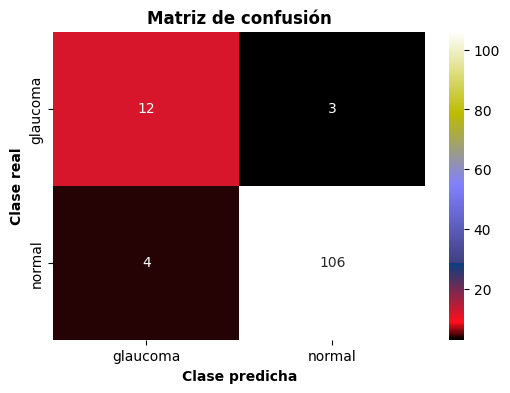

In [ ]:
cm = confusion_matrix(y_test_ext, etiquetas_predichas_ext, labels=[0., 1.])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="gist_stern", cbar=True, xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("Confusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
report_ext = classification_report(y_test_ext, etiquetas_predichas_ext, target_names=class_names)
print(report_ext)

              precision    recall  f1-score   support

    glaucoma       0.75      0.80      0.77        15
      normal       0.97      0.96      0.97       110

    accuracy                           0.94       125
   macro avg       0.86      0.88      0.87       125
weighted avg       0.95      0.94      0.94       125



In [ ]:
y_pred_prob = model.predict(X_external)
AUC = roc_auc_score(y_external, predicciones_external)
AUC_macro = roc_auc_score(y_external, predicciones_external, average="macro", multi_class="ovr")

print(f"AUC One-vs-Rest: {AUC:.4f}")
print(f"AUC Macro: {AUC_macro:.4f}")

fpr, tpr, THRESOLD_EXTERNAL = roc_curve(y_external[:, 0], y_pred_prob[:, 0])
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr  # Sensibilidad - (1 - Especificidad)
best_threshold = THRESOLD_EXTERNAL[np.argmax(J_scores)]
print(f"Best threshold based on ROC curve: {best_threshold:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
AUC One-vs-Rest: 0.9194
AUC Macro: 0.9194
Mejor umbral basado en la curva ROC: 0.012


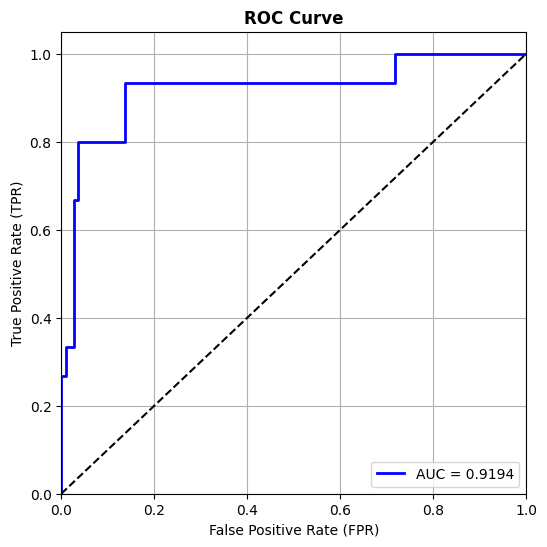

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
confidence_threshold = 0.85
subset_size = 32  

all_images = []
all_labels = []

for image_batch, label_batch in external_dataset:
    predictions = model.predict(image_batch, verbose=0)

    max_probs = np.max(predictions, axis=1)  
    predicted_labels = np.argmax(predictions, axis=1) 
    true_labels = np.argmax(label_batch, axis=1)  

    mask = (predicted_labels == true_labels) & (max_probs > confidence_threshold)

    selected_images = image_batch.numpy()[mask]
    selected_labels = label_batch.numpy()[mask]

    all_images.extend(selected_images)
    all_labels.extend(selected_labels)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

if len(all_images) < subset_size:
    print(f"Warning: They were just {len(all_images)} images with confidence > {confidence_threshold}. They will all be used.")
    subset_size = len(all_images) 

filtered_images = all_images[:subset_size]
filtered_labels = all_labels[:subset_size]

test_dataset_high_confidence = tf.data.Dataset.from_tensor_slices((filtered_images, filtered_labels))

test_dataset_high_confidence = (
    test_dataset_high_confidence
    .batch(1)  
    .prefetch(tf.data.experimental.AUTOTUNE)
)

print("Expected cardinality:", subset_size)
print("Real cardinality:", test_dataset_high_confidence.cardinality())

for image_batch, label_batch in test_dataset_high_confidence.take(1):
    print("Images shape:", image_batch.shape)  # (1, 224, 224, 3)
    print("Labels shape:", label_batch.shape)

Cardinalidad esperada: 32
Cardinalidad real: tf.Tensor(32, shape=(), dtype=int64)
Imágenes shape: (1, 224, 224, 3)
Etiquetas shape: (1, 2)


In [ ]:
subset_size = 12
test_GRADCAM2 = test_dataset_high_confidence.skip(1).take(subset_size)

for image_batch, label_batch in test_dataset_high_confidence.take(1):
    print("Images shape:", image_batch.shape)
    print("Labels shape:", label_batch.shape)

Imagenes shape: (1, 224, 224, 3)
Etiquetas shape: (1, 2)


num_figures: 12
(num_cols, num_rows): (4, 3)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_604']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


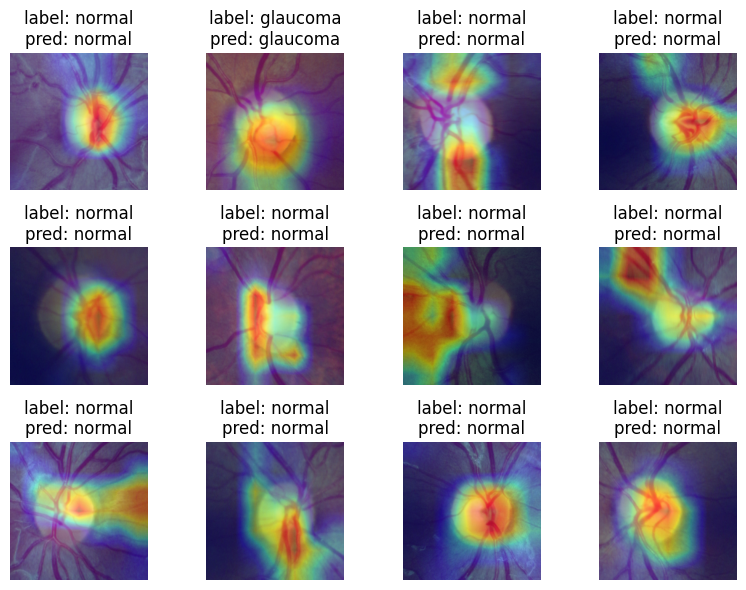

In [ ]:
visualize_gradcam(test_GRADCAM2, grad_model, class_names=class_names)

In [ ]:
# model.save('/content/drive/MyDrive/MODEL_NAME.keras') 